## **Less Code with hierarchical multi-agent**

In [ ]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model=os.getenv("QWEN_MODEL"),
    temperature=0.4
)


## **Team-1: Medical Team**

In [4]:
from pydantic import BaseModel
from langgraph.graph import MessagesState
from typing import Literal
class Tema1State(MessagesState):
    next: Literal["team_1_agent_1", "team_1_agent_2", "__end__"]

In [ ]:
##

In [5]:
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
def team_1_supervisor(state: Tema1State) -> Command[Literal["team_1_agent_1", "team_1_agent_2", "__end__"]]:
    print("--Medical Supervisor--")
    pass



In [ ]:
def team_1_agent_1(state: Tema1State) -> Command[Literal["team_1_supervisor"]]:
    pass

def team_1_agent_2(state: Tema1State) -> Command[Literal["team_1_supervisor"]]:
    pass


## team 1 sub graph state define

team_1_builder = StateGraph(Tema1State)
team_1_builder.add_node("team_1_supervisor", team_1_supervisor)
team_1_builder.add_node("team_1_agent_1", team_1_agent_1)
team_1_builder.add_node("team_1_agent_2", team_1_agent_2)

## Edges
team_1_builder.add_edge(START, "team_1_supervisor")
team_1_graph = team_1_builder.compile()
team_1_graph

## **Team-2**

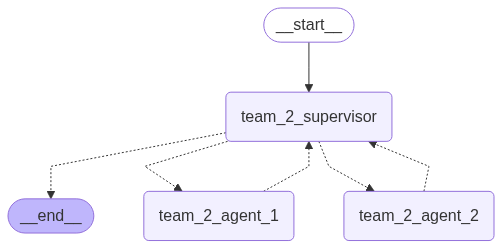

In [6]:
class Team2State(MessagesState):
    next: Literal["team_2_agent_1", "team_2_agent_2", "__end__"]
    
    
def team_2_supervisor(state: Team2State) -> Command[Literal["team_2_agent_1", "team_2_agent_2", "__end__"]]:
    pass

def team_2_agent_1(state: Team2State) -> Command[Literal["team_2_supervisor"]]:
    pass

def team_2_agent_2(state: Team2State) -> Command[Literal["team_2_supervisor"]]:
    pass

## node

team_2_builder = StateGraph(Team2State)

team_2_builder.add_node("team_2_agent_1", team_2_agent_1)
team_2_builder.add_node("team_2_agent_2", team_2_agent_2)
team_2_builder.add_node("team_2_supervisor", team_2_supervisor)

##
team_2_builder.add_edge(START, "team_2_supervisor")

team_2_graph = team_2_builder.compile()
team_2_graph

## **Define the Boss Super visor**

In [14]:
class TopState(MessagesState):
    next: Literal["team_1_graph", "team_2_graph", "__end__"]
    
def top_level_supervisor(state: TopState) -> Command[Literal["team_1_graph", "team_2_graph", "__end__"]]:
    pass


builder = StateGraph(TopState)

builder.add_node("top_level_supervisor", top_level_supervisor)
builder.add_node("team_1_graph", team_1_graph)
builder.add_node("team_2_graph", team_2_graph)
builder.add_edge(START, "top_level_supervisor")
builder.add_edge("team_1_graph", "top_level_supervisor")
builder.add_edge("team_2_graph", "top_level_supervisor")
graph = builder.compile()

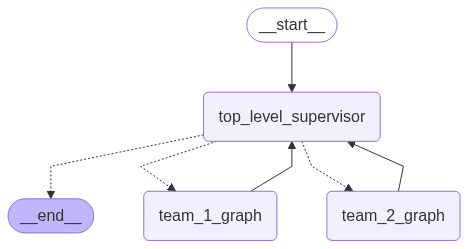

In [15]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))